<a href="https://colab.research.google.com/github/shaunyttan-cell/MDS5023_SHAUN_TAN_YAN_TAT_25119033/blob/main/MDS5023_25119033_Shaun_Tan_Yan_Tat_Assessment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

print("Please upload the 'Telco_customer_churn.xlsx' file:")
uploaded = files.upload(

)

Please upload the 'Telco_customer_churn.xlsx' file:


Saving Telco_customer_churn.xlsx to Telco_customer_churn (1).xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel('Telco_customer_churn.xlsx')

In [3]:
df.shape

(7043, 33)

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [6]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [7]:
(df['Total Charges'] == ' ').sum()

np.int64(11)

In [8]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

In [9]:
df['Total Charges'].dtype

dtype('float64')

In [10]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [11]:
cols_to_drop = [
    'CustomerID', 'Count',
    'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude',
    'Churn Value', 'Churn Score', 'Churn Reason',
    'CLTV'
]
df = df.drop(columns=cols_to_drop)


In [12]:
df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
df = df.drop('Churn Label', axis=1)
df.shape

(7043, 20)

In [28]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [29]:
df_original = df.copy()

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing']

In [30]:
for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map(binary_map)

In [42]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
1,0,0,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
2,0,0,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
3,0,0,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
4,1,0,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1


In [31]:
multi_cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

df.shape

(7043, 31)

In [32]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
1,0,0,0,1,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,1,8,1,1,99.65,820.50,1,...,False,False,True,False,True,False,False,False,True,False
3,0,0,1,1,28,1,1,104.80,3046.05,1,...,True,False,True,False,True,False,False,False,True,False
4,1,0,0,1,49,1,1,103.70,5036.30,1,...,False,False,True,False,True,False,False,False,False,False


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numerical_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts(normalize=True)}")

Training set shape: (5634, 30)
Test set shape: (1409, 30)
Class distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [34]:
print(df[['Tenure Months', 'Monthly Charges', 'Total Charges']].describe())

       Tenure Months  Monthly Charges  Total Charges
count    7043.000000      7043.000000    7043.000000
mean       32.371149        64.761692    2279.734304
std        24.559481        30.090047    2266.794470
min         0.000000        18.250000       0.000000
25%         9.000000        35.500000     398.550000
50%        29.000000        70.350000    1394.550000
75%        55.000000        89.850000    3786.600000
max        72.000000       118.750000    8684.800000


In [35]:
churn_by_contract = df_original.groupby('Contract')['Churn'].agg(['mean', 'count'])
churn_by_contract.columns = ['Churn Rate', 'Customer Count']
churn_by_contract['Churn Rate'] = (churn_by_contract['Churn Rate'] * 100).round(1)
print(churn_by_contract)

                Churn Rate  Customer Count
Contract                                  
Month-to-month        42.7            3875
One year              11.3            1473
Two year               2.8            1695


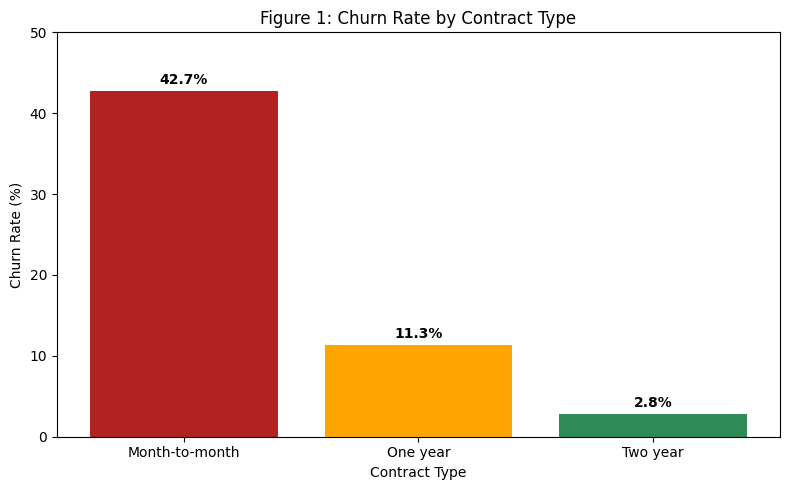

In [45]:
import matplotlib.pyplot as plt

churn_rate_contract = (df_original.groupby('Contract')['Churn'].mean() * 100).round(1)
churn_rate_contract = churn_rate_contract.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_rate_contract.index, churn_rate_contract.values,
              color=['firebrick', 'orange', 'seagreen'])

ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.set_title('Figure 1: Churn Rate by Contract Type')
ax.set_ylim(0, 50)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
churn_by_internet = df_original.groupby('Internet Service')['Churn'].agg(['mean', 'count'])
churn_by_internet.columns = ['Churn Rate', 'Customer Count']
churn_by_internet['Churn Rate'] = (churn_by_internet['Churn Rate'] * 100).round(1)
print(churn_by_internet)

                  Churn Rate  Customer Count
Internet Service                            
DSL                     19.0            2421
Fiber optic             41.9            3096
No                       7.4            1526


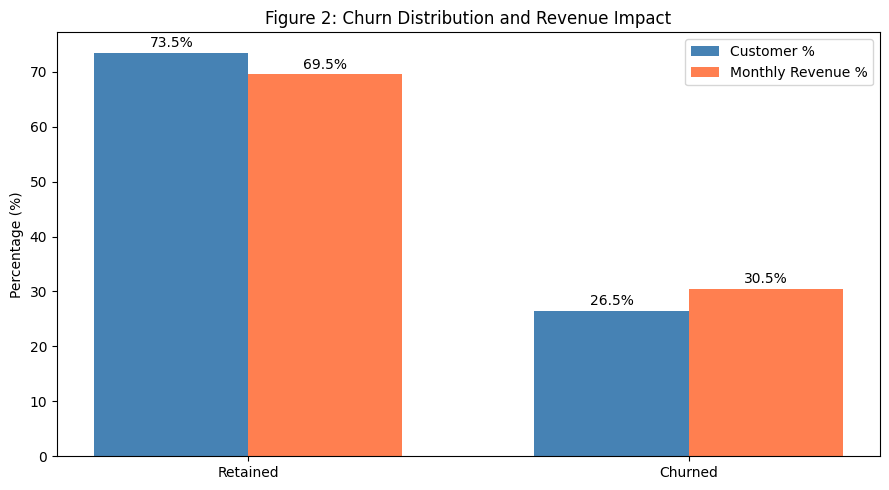

In [41]:
churn_summary = df_original.groupby('Churn').agg({
    'Churn': 'count',
    'Monthly Charges': 'sum'
}).rename(columns={'Churn': 'Customer Count', 'Monthly Charges': 'Monthly Revenue'})

churn_summary['Customer %'] = (churn_summary['Customer Count'] / churn_summary['Customer Count'].sum() * 100).round(1)
churn_summary['Revenue %'] = (churn_summary['Monthly Revenue'] / churn_summary['Monthly Revenue'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Retained', 'Churned']
customer_pct = [churn_summary.loc[0, 'Customer %'], churn_summary.loc[1, 'Customer %']]
revenue_pct = [churn_summary.loc[0, 'Revenue %'], churn_summary.loc[1, 'Revenue %']]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, customer_pct, width, label='Customer %', color='steelblue')
bars2 = ax.bar(x + width/2, revenue_pct, width, label='Monthly Revenue %', color='coral')

ax.set_ylabel('Percentage (%)')
ax.set_title('Figure 2: Churn Distribution and Revenue Impact')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

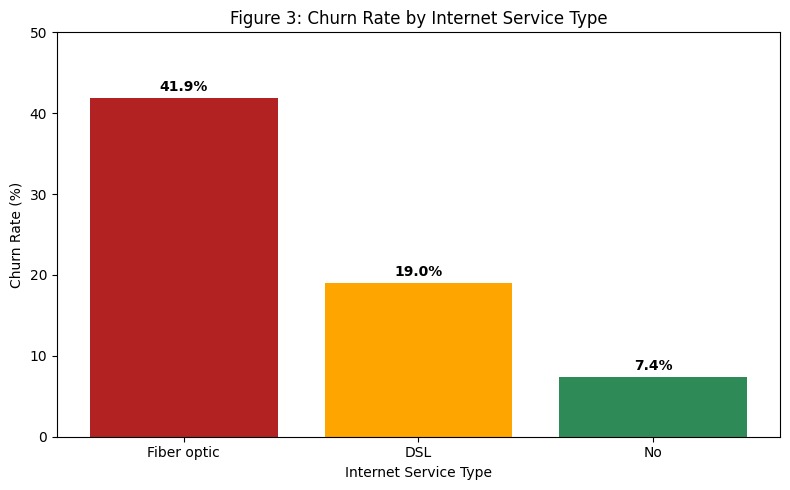

In [46]:
churn_rate_internet = (df_original.groupby('Internet Service')['Churn'].mean() * 100).round(1)
churn_rate_internet = churn_rate_internet.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(churn_rate_internet.index, churn_rate_internet.values,
              color=['firebrick', 'orange', 'seagreen'])

ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Internet Service Type')
ax.set_title('Figure 3: Churn Rate by Internet Service Type')
ax.set_ylim(0, 50)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

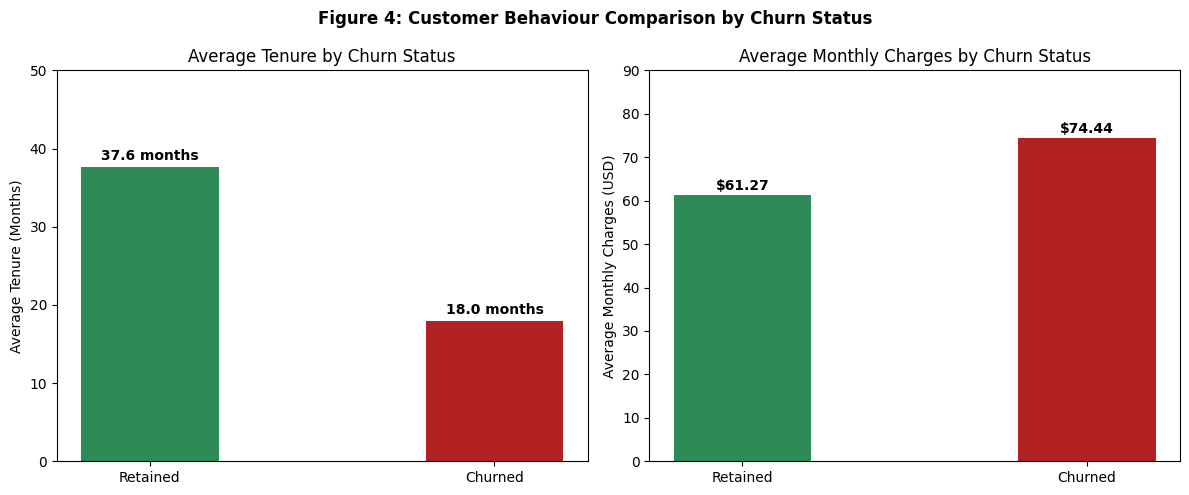

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

avg_tenure = df_original.groupby('Churn')['Tenure Months'].mean().round(1)
labels = ['Retained', 'Churned']
bars1 = axes[0].bar(labels, avg_tenure.values, color=['seagreen', 'firebrick'], width=0.4)
axes[0].set_ylabel('Average Tenure (Months)')
axes[0].set_title('Average Tenure by Churn Status')
axes[0].set_ylim(0, 50)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height} months', ha='center', va='bottom', fontweight='bold')

avg_charges = df_original.groupby('Churn')['Monthly Charges'].mean().round(2)
bars2 = axes[1].bar(labels, avg_charges.values, color=['seagreen', 'firebrick'], width=0.4)
axes[1].set_ylabel('Average Monthly Charges (USD)')
axes[1].set_title('Average Monthly Charges by Churn Status')
axes[1].set_ylim(0, 90)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'${height}', ha='center', va='bottom', fontweight='bold')

fig.suptitle('Figure 4: Customer Behaviour Comparison by Churn Status', fontweight='bold')
plt.tight_layout()
plt.show()

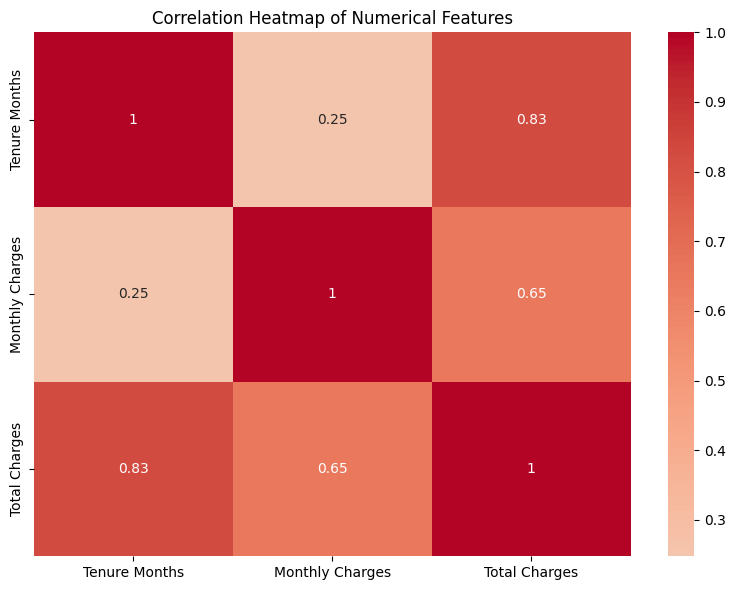

In [51]:
numerical_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [54]:
tenure_bins = pd.cut(df_original['Tenure Months'], bins=[0, 12, 24, 48, 72],
                    labels=['0-12', '13-24', '25-48', '49-72'])
churn_by_tenure = df_original.groupby(tenure_bins, observed=True)['Churn'].mean() * 100
print(churn_by_tenure)

Tenure Months
0-12     47.678161
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64


In [55]:
avg_charges_churned = np.mean(df_original[df_original['Churn']==1]['Monthly Charges'])
avg_charges_retained = np.mean(df_original[df_original['Churn']==0]['Monthly Charges'])
charges_difference = avg_charges_churned - avg_charges_retained
print(f"Average monthly charge difference: ${charges_difference:.2f}")

Average monthly charge difference: $13.18


In [56]:
def preprocess_telco_data(filepath):
    """
    Load and preprocess the Telco Customer Churn dataset.
    Handles data type conversion, column removal, and encoding.
    Returns a clean DataFrame ready for train-test splitting.
    """
    df = pd.read_excel(filepath)

    # Handle TotalCharges
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
    df['Total Charges'] = df['Total Charges'].fillna(0)

    # Drop non-predictive and target-leakage columns
    cols_to_drop = [
        'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
        'Lat Long', 'Latitude', 'Longitude', 'Churn Value', 'Churn Score',
        'Churn Reason', 'CLTV'
    ]
    df = df.drop(columns=cols_to_drop)

    # Encode target
    df['Churn'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
    df = df.drop('Churn Label', axis=1)

    # One-hot encode remaining categorical variables
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df

In [57]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Generate classification report and confusion matrix for a trained model.
    Returns the confusion matrix as a NumPy array for further analysis.
    """
    predictions = model.predict(X_test)
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, predictions))
    cm = confusion_matrix(y_test, predictions)
    return cm

In [58]:
lr_cm = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
rf_cm = evaluate_model(rf_model, X_test, y_test, "Random Forest")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



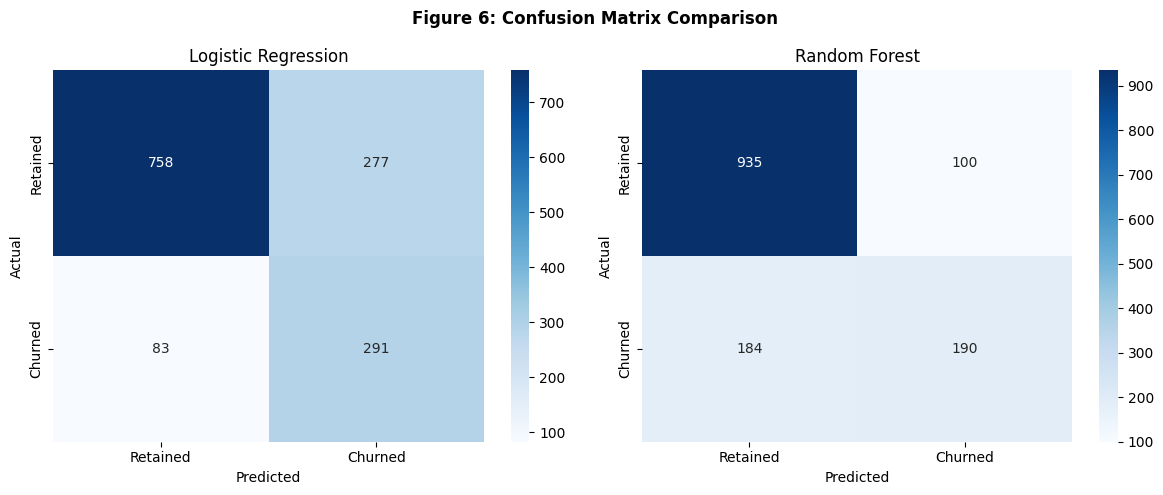

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

fig.suptitle('Figure 6: Confusion Matrix Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

In [61]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients.head(10))

                            Feature  Coefficient  Odds_Ratio
3                        Dependents    -1.622896    0.197326
26                Contract_Two year    -1.379745    0.251643
4                     Tenure Months    -1.216790    0.296179
11     Internet Service_Fiber optic     1.035607    2.816817
25                Contract_One year    -0.773395    0.461444
8                     Total Charges     0.516367    1.675927
7                   Monthly Charges    -0.425689    0.653319
28  Payment Method_Electronic check     0.399711    1.491394
24             Streaming Movies_Yes     0.365462    1.441180
22                 Streaming TV_Yes     0.345188    1.412255


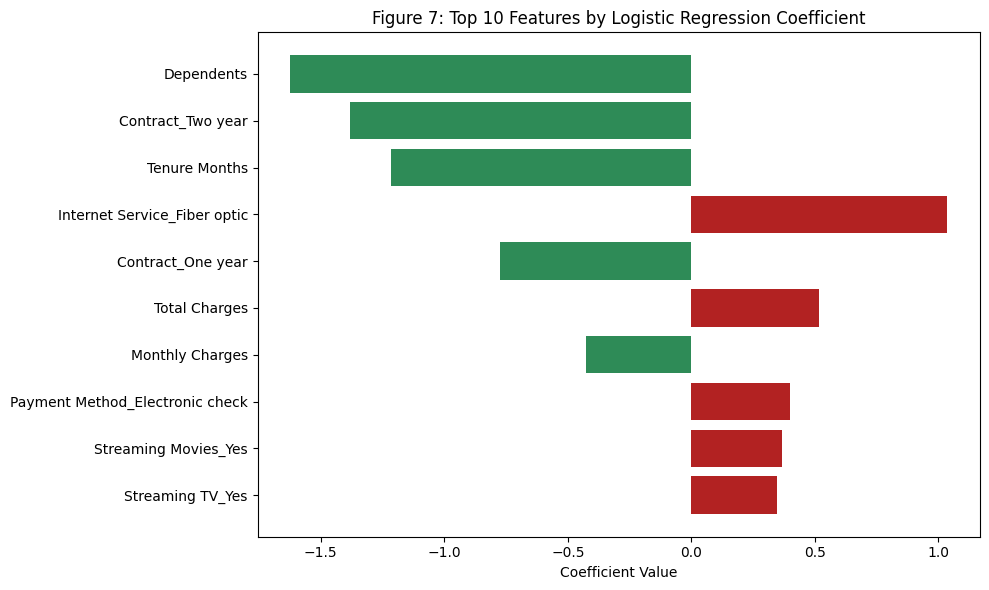

In [62]:
top_features = coefficients.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['firebrick' if c > 0 else 'seagreen' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Figure 7: Top 10 Features by Logistic Regression Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [63]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.head(10))

                            Feature  Importance
8                     Total Charges    0.172722
4                     Tenure Months    0.162603
7                   Monthly Charges    0.145095
3                        Dependents    0.052532
26                Contract_Two year    0.052250
11     Internet Service_Fiber optic    0.041688
28  Payment Method_Electronic check    0.040615
25                Contract_One year    0.027086
0                            Gender    0.024706
14              Online Security_Yes    0.024314
